# Signed Spectral Clustering Recovery on Synthetic Planted-Synergy Data

This notebook demonstrates **SPONGE signed spectral clustering** on pairwise Co-Information graphs for recovering planted synergistic modules in synthetic datasets.

**What this does:**
1. Computes a Co-Information (CoI) matrix using a custom KSG MI estimator
2. Runs SPONGE_sym signed spectral clustering (auto-k and oracle-k)
3. Compares against 3 baselines: hard thresholding, unsigned spectral, random partition
4. Reports ARI, module-focused ARI, synergistic pair Jaccard, XOR recovery fraction, and frustration index

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# joblib, loguru — NOT on Colab, always install
_pip('joblib==1.4.2')
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')
    # scipy 1.16.3 requires Python >=3.11 (Colab uses 3.12); fall back for 3.10
    try:
        _pip('scipy==1.16.3')
    except Exception:
        _pip('scipy>=1.14.0,<1.16')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


ERROR: Ignored the following versions that require a different python version: 1.16.0 Requires-Python >=3.11; 1.16.0rc1 Requires-Python >=3.11; 1.16.0rc2 Requires-Python >=3.11; 1.16.1 Requires-Python >=3.11; 1.16.2 Requires-Python >=3.11; 1.16.3 Requires-Python >=3.11; 1.17.0 Requires-Python >=3.11; 1.17.0rc1 Requires-Python >=3.11; 1.17.0rc2 Requires-Python >=3.11; 1.17.1 Requires-Python >=3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10
ERROR: Could not find a version that satisfies the requirement scipy==1.16.3 (from versions: 0.8.0, 0.9.0, 0.10.0, 0.10.1, 0.11.0, 0.12.0, 0.12.1, 0.13.0, 0.13.1, 0.13.2, 0.13.3, 0.14.0, 0.14.1, 0.15.0, 0.15.1, 0.16.0, 0.16.1, 0.17.0, 0.17.1, 0.18.0, 0.18.1, 0.19.0, 0.19.1, 1.0.0, 1.0.1, 1.1.0, 1.2.0, 1.2.1, 1.2.2, 1.2.3, 1.3.0, 1.3.1, 1.3.2, 1.3.3, 1.4.0, 1.4.1, 1.5.0, 1.5.1, 1.5.2, 1.5.3, 1.5.4, 1.6.0, 1.6.1, 1.7.2, 1.7.3, 1.8.0rc1, 1.8.0rc2, 1.8.0rc3, 1


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import sys
import time

import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from loguru import logger
from scipy.sparse.csgraph import connected_components
from scipy.spatial import cKDTree
from scipy.special import digamma
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.model_selection import StratifiedShuffleSplit

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/experiment_iter2_signed_spectral/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['variants'])} variant(s)")
for v in data['variants']:
    print(f"  {v['name']}: {v['n_samples']} samples, {v['n_features']} features")

Loaded 1 variant(s)
  easy_2mod_xor: 500 samples, 10 features


## Configuration

All tunable parameters are defined here. Start with minimum values for fast execution.

In [5]:
# ── Tunable parameters ──
COI_K = 5                # k for KSG MI estimator
SUBSAMPLE_N = 10000      # max samples for CoI computation
RANDOM_STATE = 42
NUM_WORKERS = 1          # parallel workers (1 for notebook stability)
KMEANS_N_INIT = 20       # KMeans restarts

## MI Estimation (Custom KSG / Ross-2014 Estimator)

Computes mutual information between continuous features and discrete labels using KSG-type estimator with cKDTree for efficient neighbour counting.

In [6]:
def custom_micd(X_cont: np.ndarray, y_disc: np.ndarray, k: int = 5) -> float:
    """MI between continuous X (n, d) and discrete y (n,).

    Uses the KSG-type estimator for continuous-discrete MI (Ross 2014).
    Handles duplicates via tiny jitter and vectorises the radius counting
    with ``cKDTree.query_ball_point(..., return_length=True)``.
    """
    if X_cont.ndim == 1:
        X_cont = X_cont.reshape(-1, 1)

    n = X_cont.shape[0]
    if n <= k + 1:
        return 0.0

    # Constant features -> MI = 0
    if np.all(np.ptp(X_cont, axis=0) < 1e-12):
        return 0.0

    classes, counts = np.unique(y_disc, return_counts=True)
    if len(classes) < 2:
        return 0.0

    # Tiny jitter to break ties (deterministic per call via fixed RNG copy)
    rng = np.random.RandomState(42)
    jitter = rng.randn(*X_cont.shape) * 1e-10
    X_j = X_cont + jitter

    tree_full = cKDTree(X_j)

    sum_psi_m = 0.0
    sum_psi_nc = 0.0

    for cls, cnt in zip(classes, counts):
        mask = y_disc == cls
        X_cls = X_j[mask]
        n_cls = int(cnt)

        if n_cls <= k:
            continue

        tree_cls = cKDTree(X_cls)
        dists, _ = tree_cls.query(X_cls, k=k + 1)
        eps = dists[:, -1]
        eps = np.maximum(eps, 1e-15)

        # Vectorised: count all neighbours within eps in full dataset
        m_counts = tree_full.query_ball_point(X_cls, eps, return_length=True)
        m_values = np.asarray(m_counts, dtype=np.float64) - 1  # exclude self
        m_values = np.maximum(m_values, 1)

        sum_psi_m += np.sum(digamma(m_values))
        sum_psi_nc += n_cls * digamma(n_cls)

    mi = digamma(k) + digamma(n) - sum_psi_m / n - sum_psi_nc / n
    return max(float(mi), 0.0)


def compute_mi(X_cont: np.ndarray, y_disc: np.ndarray, k: int = 5) -> float:
    """Compute MI(X; Y) for continuous X and discrete Y."""
    return custom_micd(X_cont, y_disc, k=k)

## Co-Information Matrix

Computes the d x d Co-Information matrix: `CoI[i,j] = I(Xi;Y) + I(Xj;Y) - I({Xi,Xj};Y)`. Negative values indicate synergy, positive values indicate redundancy.

In [7]:
def compute_coi_matrix(
    X: np.ndarray,
    y: np.ndarray,
    k: int = 5,
    n_subsample: int = 10000,
    n_jobs: int = 1,
) -> tuple:
    """Compute d x d Co-Information matrix."""
    n, d = X.shape

    # Stratified subsample
    if n > n_subsample:
        sss = StratifiedShuffleSplit(
            n_splits=1, train_size=n_subsample, random_state=RANDOM_STATE
        )
        idx, _ = next(sss.split(X, y))
        X_sub = X[idx].copy()
        y_sub = y[idx].copy()
        logger.info(f"  Subsampled {n} -> {n_subsample}")
    else:
        X_sub = X.copy()
        y_sub = y.copy()

    # Phase A: individual MI (d calls)
    logger.info(f"  Phase A: individual MI for {d} features ...")
    mi_individual = np.zeros(d)
    for i in range(d):
        mi_individual[i] = compute_mi(X_sub[:, i:i + 1], y_sub, k=k)
    logger.info(f"  Individual MI  [{mi_individual.min():.4f} .. "
                f"{mi_individual.max():.4f}]")

    # Phase B: joint MI (d*(d-1)/2 calls, parallelised)
    pairs = [(i, j) for i in range(d) for j in range(i + 1, d)]
    n_pairs = len(pairs)
    logger.info(f"  Phase B: joint MI for {n_pairs} pairs  "
                f"({n_jobs} workers) ...")

    def _pair_mi(i: int, j: int) -> tuple:
        X_joint = np.column_stack([X_sub[:, i], X_sub[:, j]])
        return (i, j, compute_mi(X_joint, y_sub, k=k))

    t0 = time.time()
    results = Parallel(n_jobs=n_jobs, verbose=0, backend="loky")(
        delayed(_pair_mi)(i, j) for i, j in pairs
    )
    logger.info(f"  Phase B done in {time.time() - t0:.1f}s")

    # Phase C: assemble CoI matrix
    CoI = np.zeros((d, d))
    for i, j, jmi in results:
        coi_val = mi_individual[i] + mi_individual[j] - jmi
        CoI[i, j] = coi_val
        CoI[j, i] = coi_val
    np.fill_diagonal(CoI, 0)

    return CoI, mi_individual

## SPONGE_sym Signed Spectral Clustering

Builds the SPONGE generalised eigenvalue problem from the signed CoI graph. Synergistic features (negative CoI) become positive edges kept within the same cluster.

In [8]:
def _safe_inv_sqrt(d_vec: np.ndarray) -> np.ndarray:
    out = np.zeros_like(d_vec)
    mask = d_vec > 1e-10
    out[mask] = 1.0 / np.sqrt(d_vec[mask])
    return out


def _build_sponge_matrices(CoI, tau_p=1.0, tau_n=1.0):
    """Build SPONGE_sym generalised eigenvalue matrices.
    Negate CoI so synergy becomes positive edges."""
    d = CoI.shape[0]
    signed_adj = -CoI
    A_pos = np.maximum(signed_adj, 0)
    A_neg = np.maximum(-signed_adj, 0)
    d_pos = A_pos.sum(axis=1)
    d_neg = A_neg.sum(axis=1)
    D_pos_inv = np.diag(_safe_inv_sqrt(d_pos))
    D_neg_inv = np.diag(_safe_inv_sqrt(d_neg))
    L_pos = np.diag(d_pos) - A_pos
    L_neg = np.diag(d_neg) - A_neg
    L_sym_pos = D_pos_inv @ L_pos @ D_pos_inv
    L_sym_neg = D_neg_inv @ L_neg @ D_neg_inv
    A_mat = L_sym_pos + tau_n * np.eye(d)
    B_mat = L_sym_neg + tau_p * np.eye(d)
    B_mat += 1e-10 * np.eye(d)
    return A_mat, B_mat


def sponge_sym(CoI, k, tau_p=1.0, tau_n=1.0):
    """SPONGE_sym signed spectral clustering. Returns (labels, eigenvalues)."""
    d = CoI.shape[0]
    k = max(2, min(k, d - 1))
    A_mat, B_mat = _build_sponge_matrices(CoI, tau_p, tau_n)
    try:
        eigenvalues, eigenvectors = scipy.linalg.eigh(
            A_mat, B_mat, subset_by_index=[0, k - 1]
        )
    except scipy.linalg.LinAlgError:
        A2, B2 = _build_sponge_matrices(CoI, tau_p * 5, tau_n * 5)
        eigenvalues, eigenvectors = scipy.linalg.eigh(
            A2, B2, subset_by_index=[0, k - 1]
        )
    norms = np.linalg.norm(eigenvectors, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-12)
    eigenvectors_normed = eigenvectors / norms
    try:
        labels = KMeans(
            n_clusters=k, n_init=KMEANS_N_INIT, random_state=RANDOM_STATE
        ).fit_predict(eigenvectors_normed)
    except Exception:
        labels = np.arange(d) % k
    return labels, eigenvalues


def select_k(CoI, k_max=None, tau_p=1.0, tau_n=1.0):
    """Automatic k selection via eigengap + silhouette."""
    d = CoI.shape[0]
    if k_max is None:
        k_max = min(20, d // 3)
    k_max = max(k_max, 3)
    A_mat, B_mat = _build_sponge_matrices(CoI, tau_p, tau_n)
    n_eigs = min(k_max, d - 1)
    try:
        eigenvalues, eigenvectors = scipy.linalg.eigh(
            A_mat, B_mat, subset_by_index=[0, n_eigs - 1]
        )
    except scipy.linalg.LinAlgError:
        return max(2, int(np.ceil(np.sqrt(d / 2))))
    gaps = np.diff(eigenvalues)
    if len(gaps) == 0:
        return 2
    top_idxs = np.argsort(gaps)[-min(3, len(gaps)):][::-1]
    top3_k = [int(idx + 2) for idx in top_idxs if 2 <= idx + 2 <= k_max]
    if not top3_k:
        top3_k = [2]
    best_k, best_sil = top3_k[0], -1.0
    for k_cand in top3_k:
        if k_cand > eigenvectors.shape[1]:
            continue
        try:
            lbl = KMeans(
                n_clusters=k_cand, n_init=KMEANS_N_INIT, random_state=RANDOM_STATE
            ).fit_predict(eigenvectors[:, :k_cand])
            if len(set(lbl)) < 2:
                continue
            sil = silhouette_score(eigenvectors[:, :k_cand], lbl)
            if sil > best_sil:
                best_k, best_sil = k_cand, sil
        except Exception:
            continue
    if len(gaps) > 0 and gaps.max() < 2 * np.median(gaps) and best_sil < 0.1:
        best_k = max(2, int(np.ceil(np.sqrt(d / 2))))
    logger.info(f"  Auto-k: k={best_k}  (silhouette={best_sil:.3f})")
    return best_k

## Frustration Index, Baselines, and Evaluation Metrics

- **Frustration index**: ratio of smallest to largest eigenvalue of the signed Laplacian (low = clean modules, high = frustrated)
- **Baselines**: hard thresholding, unsigned spectral clustering, random partition
- **Metrics**: ARI, module-focused ARI, synergistic pair Jaccard, XOR recovery fraction

In [9]:
def compute_frustration_index(CoI: np.ndarray) -> float:
    """lambda_min / lambda_max of the signed Laplacian."""
    D_bar = np.diag(np.abs(CoI).sum(axis=1))
    L_sigma = D_bar - CoI
    try:
        evals = scipy.linalg.eigvalsh(L_sigma)
    except scipy.linalg.LinAlgError:
        return 0.0
    lmin = max(evals[0], 0.0)
    lmax = evals[-1]
    if lmax < 1e-10:
        return 0.0
    return float(lmin / lmax)


def hard_threshold_baseline(CoI, quantile=0.9):
    """Baseline A: threshold synergy at quantile, connected components."""
    d = CoI.shape[0]
    synergy = np.maximum(-CoI, 0)
    upper = synergy[np.triu_indices(d, k=1)]
    nz = upper[upper > 1e-10]
    if len(nz) == 0:
        return np.arange(d)
    thr = np.quantile(nz, quantile)
    adj = (synergy >= thr).astype(np.int32)
    np.fill_diagonal(adj, 0)
    _, labels = connected_components(adj, directed=False)
    return labels


def unsigned_spectral_baseline(CoI, k):
    """Baseline B: standard spectral clustering on |CoI|."""
    d = CoI.shape[0]
    k = max(2, min(k, d - 1))
    W = np.abs(CoI)
    np.fill_diagonal(W, 0)
    dv = W.sum(axis=1)
    Di = np.diag(_safe_inv_sqrt(dv))
    L = np.diag(dv) - W
    Ls = Di @ L @ Di
    try:
        _, vecs = scipy.linalg.eigh(Ls, subset_by_index=[0, k - 1])
    except scipy.linalg.LinAlgError:
        return np.arange(d) % k
    try:
        return KMeans(
            n_clusters=k, n_init=KMEANS_N_INIT, random_state=RANDOM_STATE
        ).fit_predict(vecs)
    except Exception:
        return np.arange(d) % k


def random_partition_baseline(d, k, seed=42):
    """Baseline C: random assignment."""
    return np.random.default_rng(seed).integers(0, k, size=d)


def construct_ground_truth_labels(meta):
    """Feature-level ground-truth labels."""
    d = meta["n_features"]
    labels = np.full(d, -1, dtype=int)
    gt_modules = meta.get("ground_truth_modules", [])
    for mod_idx, mod in enumerate(gt_modules):
        for feat in mod:
            if labels[feat] == -1:
                labels[feat] = mod_idx
    for src, cpy in meta.get("redundant_pairs", []):
        if labels[src] >= 0 and labels[cpy] == -1:
            labels[cpy] = labels[src]
    next_lbl = len(gt_modules)
    for feat in range(d):
        if labels[feat] == -1:
            labels[feat] = next_lbl
            next_lbl += 1
    return labels


def compute_synergistic_pair_jaccard(gt_modules, pred_labels):
    """Jaccard over same-module feature pairs."""
    S_true = set()
    for mod in gt_modules:
        for ii in range(len(mod)):
            for jj in range(ii + 1, len(mod)):
                S_true.add((min(mod[ii], mod[jj]), max(mod[ii], mod[jj])))
    if not S_true:
        return 1.0
    gt_feats = sorted({f for mod in gt_modules for f in mod})
    S_pred = set()
    for ii in range(len(gt_feats)):
        for jj in range(ii + 1, len(gt_feats)):
            fi, fj = gt_feats[ii], gt_feats[jj]
            if pred_labels[fi] == pred_labels[fj]:
                S_pred.add((min(fi, fj), max(fi, fj)))
    inter = len(S_true & S_pred)
    union = len(S_true | S_pred)
    return inter / union if union else 1.0


def compute_xor_recovery(gt_modules, module_types, pred_labels):
    """Fraction of XOR modules whose features all land in ONE cluster."""
    xor_mods = [m for m, t in zip(gt_modules, module_types) if "xor" in t]
    if not xor_mods:
        return None
    recovered = sum(
        1 for m in xor_mods
        if len({int(pred_labels[f]) for f in m}) == 1
    )
    return recovered / len(xor_mods)


def compute_module_focused_ari(gt_labels, pred_labels, meta):
    """ARI computed only on module + redundant features (ignoring noise)."""
    module_feats = set()
    for mod in meta.get("ground_truth_modules", []):
        module_feats.update(mod)
    for src, cpy in meta.get("redundant_pairs", []):
        module_feats.add(src)
        module_feats.add(cpy)
    if len(module_feats) < 2:
        return None
    idx = sorted(module_feats)
    return float(adjusted_rand_score(gt_labels[idx], pred_labels[idx]))

## Run Experiment

Process each variant: compute CoI matrix, run SPONGE and baselines, evaluate metrics.

In [10]:
overall_t0 = time.time()
all_variant_results = {}

for variant_data in data['variants']:
    name = variant_data['name']
    X = np.array(variant_data['X'])
    y = np.array(variant_data['y'])
    meta = variant_data['meta']
    d = X.shape[1]

    logger.info(f"\n{'─'*55}")
    logger.info(f"  {name}  (n={X.shape[0]}, d={d})")
    logger.info(f"{'─'*55}")

    # CoI matrix
    t0 = time.time()
    CoI, mi_individual = compute_coi_matrix(
        X, y, k=COI_K, n_subsample=SUBSAMPLE_N, n_jobs=NUM_WORKERS,
    )
    t_coi = time.time() - t0
    logger.info(f"  CoI matrix: {t_coi:.1f}s")

    # Diagnostics
    gt_modules = meta.get("ground_truth_modules", [])
    module_types = meta.get("module_types", [])

    # Frustration index
    frustration = compute_frustration_index(CoI)
    logger.info(f"  Frustration index: {frustration:.4f}")

    # Ground truth
    gt_k = len(gt_modules) if gt_modules else 0
    gt_labels = construct_ground_truth_labels(meta)

    # SPONGE (auto k)
    t0 = time.time()
    auto_k = select_k(CoI) if d >= 4 else max(gt_k, 2)
    sponge_auto_lbl, sponge_auto_ev = sponge_sym(CoI, k=auto_k)
    t_sponge_auto = time.time() - t0

    # SPONGE (oracle k)
    t0 = time.time()
    if gt_k >= 2:
        sponge_orc_lbl, sponge_orc_ev = sponge_sym(CoI, k=gt_k)
    else:
        sponge_orc_lbl = np.arange(d)
        sponge_orc_ev = np.array([])
    t_sponge_orc = time.time() - t0

    # Baselines
    k_bl = gt_k if gt_k >= 2 else auto_k
    ht_lbl = hard_threshold_baseline(CoI)
    us_lbl = unsigned_spectral_baseline(CoI, k=k_bl)
    rn_lbl = random_partition_baseline(d, k=k_bl)

    # Evaluate
    methods = {
        "sponge_auto_k": {"labels": sponge_auto_lbl, "k": int(auto_k), "time": t_sponge_auto},
        "sponge_oracle_k": {"labels": sponge_orc_lbl, "k": int(gt_k), "time": t_sponge_orc},
        "hard_threshold": {"labels": ht_lbl, "k": int(len(set(ht_lbl.tolist()))), "time": 0},
        "unsigned_spectral": {"labels": us_lbl, "k": int(k_bl), "time": 0},
        "random_partition": {"labels": rn_lbl, "k": int(k_bl), "time": 0},
    }

    variant_metrics = {
        "name": name, "n_features": d, "gt_n_modules": gt_k,
        "frustration_index": round(float(frustration), 6),
        "coi_time": round(t_coi, 2), "methods": {},
        "CoI": CoI, "mi_individual": mi_individual,
    }

    for mname, mdata in methods.items():
        pred = mdata["labels"]
        if gt_k >= 1:
            ari = float(adjusted_rand_score(gt_labels, pred))
            mf_ari = compute_module_focused_ari(gt_labels, pred, meta)
            jac = float(compute_synergistic_pair_jaccard(gt_modules, pred))
            xrf = compute_xor_recovery(gt_modules, module_types, pred)
        else:
            ari = mf_ari = jac = xrf = None

        variant_metrics["methods"][mname] = {
            "k_used": mdata["k"],
            "ari": round(ari, 6) if ari is not None else None,
            "module_focused_ari": round(mf_ari, 6) if mf_ari is not None else None,
            "jaccard": round(jac, 6) if jac is not None else None,
            "xor_recovery": round(float(xrf), 6) if xrf is not None else None,
            "labels": pred,
        }

        a_s = f"ARI={ari:.3f}" if ari is not None else "ARI=N/A"
        j_s = f"Jac={jac:.3f}" if jac is not None else "Jac=N/A"
        x_s = f"XOR={xrf:.3f}" if xrf is not None else "XOR=N/A"
        logger.info(f"    {mname}: {a_s} {j_s} {x_s}")

    all_variant_results[name] = variant_metrics

total_time = time.time() - overall_t0
logger.info(f"\nTotal wall-clock: {total_time:.1f}s")

11:15:32|INFO   |
───────────────────────────────────────────────────────


11:15:32|INFO   |  easy_2mod_xor  (n=500, d=10)


11:15:32|INFO   |───────────────────────────────────────────────────────


11:15:32|INFO   |  Phase A: individual MI for 10 features ...


11:15:32|INFO   |  Individual MI  [0.0000 .. 0.0526]


...

11:15:33|INFO   |    sponge_oracle_k: ARI=0.299 Jac=1.000 XOR=1.000


11:15:33|INFO   |    hard_threshold: ARI=0.776 Jac=1.000 XOR=1.000


11:15:33|INFO   |    unsigned_spectral: ARI=0.237 Jac=1.000 XOR=1.000


11:15:33|INFO   |    random_partition: ARI=-0.075 Jac=0.000 XOR=0.000


11:15:33|INFO   |
Total wall-clock: 0.7s


## Results Visualization

Summary table comparing all methods, Co-Information heatmap, and metric bar chart.

RESULTS SUMMARY

Variant: easy_2mod_xor  (d=10, gt_modules=2, frustration=0.0427)
  CoI computation: 0.06s
  Method                   k      ARI    mfARI  Jaccard      XOR
  ------------------------------------------------------------
  sponge_auto_k            3    0.508    1.000    1.000    1.000
  sponge_oracle_k          2    0.299    1.000    1.000    1.000
  hard_threshold           7    0.776    0.706    1.000    1.000
  unsigned_spectral        2    0.237    1.000    1.000    1.000
  random_partition         2   -0.075   -0.111    0.000    0.000

Total runtime: 0.7s


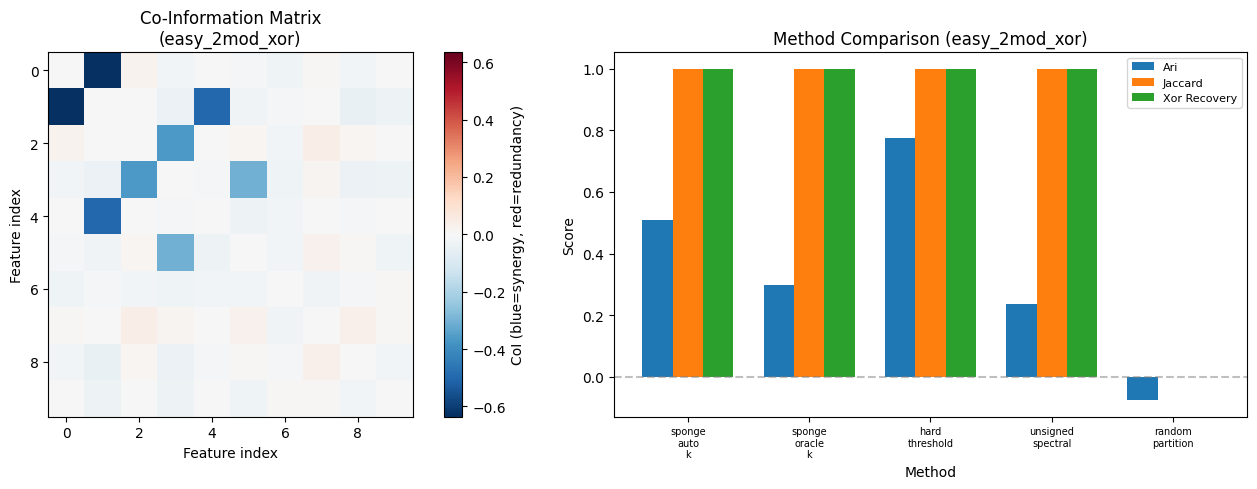

Plot saved to results.png


In [11]:
# ── Results Table ──
print("=" * 80)
print("RESULTS SUMMARY")
print("=" * 80)

for vname, vdata in all_variant_results.items():
    print(f"\nVariant: {vname}  (d={vdata['n_features']}, "
          f"gt_modules={vdata['gt_n_modules']}, "
          f"frustration={vdata['frustration_index']:.4f})")
    print(f"  CoI computation: {vdata['coi_time']:.2f}s")
    print(f"  {'Method':<22s} {'k':>3s} {'ARI':>8s} {'mfARI':>8s} "
          f"{'Jaccard':>8s} {'XOR':>8s}")
    print("  " + "-" * 60)
    for mname, mmetrics in vdata['methods'].items():
        ari_s = f"{mmetrics['ari']:.3f}" if mmetrics['ari'] is not None else "N/A"
        mf_s = f"{mmetrics['module_focused_ari']:.3f}" if mmetrics['module_focused_ari'] is not None else "N/A"
        jac_s = f"{mmetrics['jaccard']:.3f}" if mmetrics['jaccard'] is not None else "N/A"
        xor_s = f"{mmetrics['xor_recovery']:.3f}" if mmetrics['xor_recovery'] is not None else "N/A"
        print(f"  {mname:<22s} {mmetrics['k_used']:>3d} {ari_s:>8s} "
              f"{mf_s:>8s} {jac_s:>8s} {xor_s:>8s}")

print(f"\nTotal runtime: {total_time:.1f}s")

# ── Plots ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: CoI heatmap for first variant
vname = list(all_variant_results.keys())[0]
vdata = all_variant_results[vname]
CoI = vdata['CoI']
im = axes[0].imshow(CoI, cmap='RdBu_r', aspect='equal',
                     vmin=-np.abs(CoI).max(), vmax=np.abs(CoI).max())
axes[0].set_title(f'Co-Information Matrix\n({vname})')
axes[0].set_xlabel('Feature index')
axes[0].set_ylabel('Feature index')
plt.colorbar(im, ax=axes[0], label='CoI (blue=synergy, red=redundancy)')

# Plot 2: Method comparison bar chart
method_names = list(vdata['methods'].keys())
metric_keys = ['ari', 'jaccard', 'xor_recovery']
x = np.arange(len(method_names))
width = 0.25

for i, mk in enumerate(metric_keys):
    vals = []
    for mn in method_names:
        v = vdata['methods'][mn].get(mk)
        vals.append(v if v is not None else 0)
    axes[1].bar(x + i * width, vals, width, label=mk.replace('_', ' ').title())

axes[1].set_xlabel('Method')
axes[1].set_ylabel('Score')
axes[1].set_title(f'Method Comparison ({vname})')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels([m.replace('_', '\n') for m in method_names],
                         fontsize=7, rotation=0)
axes[1].legend(fontsize=8)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('results.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved to results.png")